In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

For this notebook to run, you should have the file:
`UCSD_AllSites_Merge_PostProcessedSession_20210504_20240930.csv` in the same folder.

The post processed garage level files will be stored in `./UCSD_garage_datasets_PF`

## Read UCSD PowerFlex data

In [5]:
df_ucsd_pf = pd.read_csv(
    Path("UCSD_AllSites_Merge_PostProcessedSession_20210504_20240930.csv"),
    usecols=[1, 2, 10, 11, 12, 27],
)
df_ucsd_pf["Interval average demand kW"] = (
    df_ucsd_pf["Interval average demand kW"]
    .replace(["No data available", "-"], np.nan)
    .astype(float)
)
df_ucsd_pf["Interval kWh"] = (
    df_ucsd_pf["Interval kWh"].replace(["No data available", "-"], np.nan).astype(float)
)

# for the missing values in the "Interval average demand kW" column,
# we will fill them with the kWh values divided by the interval length in hours
df_ucsd_pf["Interval average demand kW"] = df_ucsd_pf[
    "Interval average demand kW"
].fillna(df_ucsd_pf["Interval kWh"] / 0.25)

C:\Users\L1131272\AppData\Local\Temp\ipykernel_30296\4232937672.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ucsd_pf = pd.read_csv(


In [ ]:
df_ucsd_pf.columns

Index(['Interval ID', 'Interval start', 'Interval end', 'Session ID',
       '10-digit UID', 'Serial #_x', 'XB Address', 'Type', 'FSE ID',
       'EVSEID (PFID)', 'Interval kWh', 'Interval max demand kW',
       'Interval average demand kW', 'Site Location', 'Session start',
       'Session end', 'Session duration (minutes)',
       'Charging duration (minutes)', 'Session idle (minutes)',
       'kWh delivered', 'SoC Start', 'SoC End', 'User', 'Vehicle',
       'EVSE Status', 'Serial #_y', 'Parking Space', 'Site', 'Cost to site',
       'Cost to driver', 'Fleet', 'Vehicle barcode', 'Minutes available',
       'Miles needed', 'Energy needed', 'Energy unit', 'Wh per mile',
       'Car Year', 'Car Make', 'Car Model', 'Car Battery'],
      dtype='object')

### Check for consistent interval length

In [ ]:
df_ucsd_pf_copy = df_ucsd_pf.copy()
df_ucsd_pf_copy = df_ucsd_pf_copy[
    ["Interval start", "Interval end", "Interval average demand kW", "Site"]
]
df_ucsd_pf_copy["Interval start"] = pd.to_datetime(df_ucsd_pf_copy["Interval start"])
df_ucsd_pf_copy["Interval end"] = pd.to_datetime(
    df_ucsd_pf_copy["Interval end"], format="mixed"
)

In [ ]:
# Check that the interval length (between interval start and end) is always the same (15 minutes)
df_ucsd_pf_copy["Interval length"] = (
    df_ucsd_pf_copy["Interval end"] - df_ucsd_pf_copy["Interval start"]
)
df_ucsd_pf_copy[df_ucsd_pf_copy["Interval length"] != pd.Timedelta("15 minutes")]
# We can see that it's when we have the daylight saving time change. therefore we can ignore those.
# This confirms that the interval length is always 15 minutes

,Interval start,Interval end,Interval average demand kW,Site,Interval length
99914,2021-11-07 01:45:00,2021-11-07 01:00:00,0.0,Athena Garage,-1 days +23:15:00
183690,2022-03-13 01:45:00,2022-03-13 03:00:00,0.0,Athena Garage,0 days 01:15:00
378144,2022-11-06 01:45:00,2022-11-06 01:00:00,0.0,Athena Garage,-1 days +23:15:00
570010,2022-11-06 01:45:00,2022-11-06 01:00:00,4.575,Athena Garage,-1 days +23:15:00
795303,2024-03-10 01:45:00,2024-03-10 03:00:00,0,UCSD Hopkins Parking Structure,0 days 01:15:00
818212,2024-03-10 01:45:00,2024-03-10 03:00:00,0,UCSD Pangea Parking Structure,0 days 01:15:00
818525,2024-03-10 01:45:00,2024-03-10 03:00:00,0,UCSD - Athena Garage,0 days 01:15:00
818583,2024-03-10 01:45:00,2024-03-10 03:00:00,6.39,UCSD - Athena Garage,0 days 01:15:00
819654,2024-03-10 01:45:00,2024-03-10 03:00:00,0,UCSD Gilman Parking Structure,0 days 01:15:00
819796,2024-03-10 01:45:00,2024-03-10 03:00:00,3.002,UCSD Pangea Parking Structure,0 days 01:15:00


### Read main file

In [2]:
# read main file
df_ucsd_pf = pd.read_csv(
    "UCSD_AllSites_Merge_PostProcessedSession_20210504_20240930.csv",
    usecols=[1, 2, 10, 11, 12, 27],
)

# convert the columns to float type (need to handle the format of the missing values)
df_ucsd_pf["Interval average demand kW"] = (
    df_ucsd_pf["Interval average demand kW"]
    .replace(["No data available", "-"], np.nan)
    .astype(float)
)
df_ucsd_pf["Interval kWh"] = (
    df_ucsd_pf["Interval kWh"].replace(["No data available", "-"], np.nan).astype(float)
)

# for the missing values in the "Interval average demand kW" column,
# we will fill them with the kWh values divided by the interval length in hours
df_ucsd_pf["Interval average demand kW"] = df_ucsd_pf[
    "Interval average demand kW"
].fillna(df_ucsd_pf["Interval kWh"] / 0.25)

C:\Users\L1131272\AppData\Local\Temp\ipykernel_28812\3883639139.py:2: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ucsd_pf = pd.read_csv(


In [3]:
df_ucsd_pf_copy = df_ucsd_pf.copy()
df_ucsd_pf_copy = df_ucsd_pf_copy[
    ["Interval start", "Interval average demand kW", "Site"]
]

# Rename the Athena garage because it has two names
df_ucsd_pf_copy["Site"] = df_ucsd_pf_copy["Site"].apply(
    lambda x: "UCSD - Athena Garage" if x == "Athena Garage" else x
)
df_ucsd_pf_copy["Interval start"] = pd.to_datetime(df_ucsd_pf_copy["Interval start"])
df_ucsd_pf_copy = df_ucsd_pf_copy.rename(
    columns={"Interval average demand kW": "power", "Interval start": "date"}
)

# convert power from kW to W
df_ucsd_pf_copy["power"] = df_ucsd_pf_copy["power"] * 1000
df_ucsd_pf_copy

,date,power,Site
0,2021-05-04 18:00:00,0.0,UCSD - Athena Garage
1,2021-05-04 17:45:00,0.0,UCSD - Athena Garage
2,2021-05-04 17:30:00,0.0,UCSD - Athena Garage
3,2021-05-04 17:15:00,0.0,UCSD - Athena Garage
4,2021-05-04 17:00:00,0.0,UCSD - Athena Garage
...,...,...,...
1713100,2021-05-04 09:00:00,0.0,UCSD - Athena Garage
1713101,2021-05-04 08:45:00,0.0,UCSD - Athena Garage
1713102,2021-05-04 08:30:00,0.0,UCSD - Athena Garage
1713103,2021-05-04 08:15:00,0.0,UCSD - Athena Garage


### Check for missing data

Here are two functions to find and interpolate missing data

In [161]:
def get_df_missing_intervals(df: pd.DataFrame) -> pd.DataFrame:
    # find all intervalls with missing data
    df_missing_intervals = df.dropna(subset=["power"]).copy()

    # find the difference between two data points
    df_missing_intervals["diff"] = df_missing_intervals["date"].diff()
    # dates are missing if the difference is not 5 minutes
    df_missing_intervals = df_missing_intervals[
        df_missing_intervals["diff"] > pd.Timedelta("15min")
    ]

    # define start and end dates of missing intervals
    df_missing_intervals["start_na"] = (
        df_missing_intervals["date"]
        - df_missing_intervals["diff"]
        + pd.Timedelta("15min")
    )
    df_missing_intervals["end_na"] = df_missing_intervals["date"] - pd.Timedelta(
        "15min"
    )
    return df_missing_intervals

In [162]:
from pandas.tseries.holiday import USFederalHolidayCalendar as us_calendar


def interpolate_missing_data(
    power_df_like: pd.DataFrame,
    max_intervaL_length_to_interpolate: pd.Timedelta = pd.Timedelta("5h"),
) -> pd.DataFrame:
    """Function to interpolate missing data
    The function performs two different interpolations when it makes sense:
        1. For missing intervals of less than max_intervaL_length_to_interpolate,
            it interpolates the first half of the interval with the previous value
            (before the start of the interval) and the second half with the next
            value (after the end of the interval).
        2. For missing intervals of less than 24 hours and during the night
            or over a weekend/holidays, it interpolates the missing interval at 0.
    """
    power_df_total_power_interpolated = power_df_like.copy()

    df_missing_intervals = get_df_missing_intervals(power_df_total_power_interpolated)
    number_of_missing_intervals = df_missing_intervals.shape[0]

    if number_of_missing_intervals == 0:
        print("No missing intervals to interpolate.")
        return power_df_like

    cal = us_calendar()
    holidays = cal.holidays(
        start=power_df_like["date"].iloc[0], end=power_df_like["date"].iloc[-1]
    )

    buffer = pd.Timedelta("15min")
    print(
        f"Start of interpolation, there are {number_of_missing_intervals} "
        f"intervals to interpolate."
    )
    interpolated_intervals = 0
    interpolated_intervals_at_0 = 0  # count the intervals that are longer and
    # therefore interpolated at 0 (if it is a weekend or during the night,
    # we can assume that there is no usage)

    for i, missing_interval in tqdm(
        df_missing_intervals.iterrows(), total=number_of_missing_intervals
    ):
        if missing_interval["diff"] < max_intervaL_length_to_interpolate:

            first_half_mask = power_df_total_power_interpolated["date"].between(
                missing_interval["start_na"] - buffer,
                missing_interval["end_na"] - missing_interval["diff"] // 2,
            )
            power_df_total_power_interpolated.loc[first_half_mask] = (
                power_df_total_power_interpolated.loc[first_half_mask].ffill()
            )

            second_half_mask = power_df_total_power_interpolated["date"].between(
                missing_interval["end_na"] - missing_interval["diff"] // 2,
                missing_interval["end_na"] + buffer,
            )
            power_df_total_power_interpolated.loc[second_half_mask] = (
                power_df_total_power_interpolated.loc[second_half_mask].bfill()
            )
            interpolated_intervals += 1
        elif (
            (  # interval during the night
                (
                    missing_interval["start_na"].hour >= 16
                    or missing_interval["start_na"].hour <= 4
                )
                and (missing_interval["end_na"].hour < 12)
            )
            or (  # interval during weekend
                (missing_interval["start_na"].weekday() >= 5)
                or (missing_interval["end_na"].weekday() >= 5)
                or missing_interval["start_na"].date() in (holidays.date)
                or missing_interval["end_na"].date() in (holidays.date)
            )
        ) and (  # we only interpolate night or weekend missing
            # intervals that are less than 24 hours
            missing_interval["diff"]
            < pd.Timedelta("24h")
        ):
            mask = power_df_total_power_interpolated["date"].between(
                missing_interval["start_na"], missing_interval["end_na"]
            )
            power_df_total_power_interpolated.loc[mask, "power"] = (
                power_df_total_power_interpolated.loc[mask, "power"].fillna(0)
            )

            interpolated_intervals += 1
            interpolated_intervals_at_0 += 1

    print(
        f"End of interpolation, {interpolated_intervals} intervals of less than "
        f"{max_intervaL_length_to_interpolate} "
        f"were interpolated ({interpolated_intervals/number_of_missing_intervals*100:.2f}%). "
        f"This includes {interpolated_intervals_at_0} intervals interpolated at 0 "
        "(night or weekends)"
    )
    return power_df_total_power_interpolated

### Function to clean group

In [163]:
def clean_group(df: pd.DataFrame):
    df = df.reset_index()

    df = df.sort_values("date")

    df = df.set_index("date").asfreq("15min").reset_index()
    df = interpolate_missing_data(df)
    df = df.dropna()  # We drop what can't be interpolated

    # Add a column for workday boolean
    df["workday"] = (df["date"].dt.dayofweek < 5).astype(int)
    return df

In [164]:
test = df_ucsd_pf_copy.groupby(["Site", "date"]).sum().loc["UCSD - 8980 La Jolla Drive"]
display(test)
test = clean_group(test)
test

,power
date,
2024-05-29 11:30:00,0.0
2024-06-04 15:15:00,0.0
2024-06-10 15:30:00,0.0
2024-06-10 15:45:00,2811.0
2024-06-10 16:00:00,5555.0
...,...
2024-09-25 10:30:00,6168.0
2024-09-25 10:45:00,6442.0
2024-09-25 11:00:00,6441.0


Start of interpolation, there are 54 intervals to interpolate.


  0%|          | 0/54 [00:00<?, ?it/s]

End of interpolation, 18 intervals of less than 0 days 05:00:00 were interpolated (33.33%). This includes 10 intervals interpolated at 0 (night or weekends)


,date,power,workday
0,2024-05-29 11:30:00,0.0,1
591,2024-06-04 15:15:00,0.0,1
1168,2024-06-10 15:30:00,0.0,1
1169,2024-06-10 15:45:00,2811.0,1
1170,2024-06-10 16:00:00,5555.0,1
...,...,...,...
11420,2024-09-25 10:30:00,6168.0,1
11421,2024-09-25 10:45:00,6442.0,1
11422,2024-09-25 11:00:00,6441.0,1
11423,2024-09-25 11:15:00,6128.0,1


### Make dataset for each garage

In [165]:
garage_datasets_folder = Path("UCSD_garage_datasets_PF")
os.makedirs(garage_datasets_folder, exist_ok=True)

df_ucsd_grouped = df_ucsd_pf_copy.groupby(["Site", "date"]).sum()

for garage_name in df_ucsd_grouped.index.get_level_values(0).unique():
    df_garage = df_ucsd_grouped.loc[garage_name]

    df_garage = clean_group(df_garage)
    # Save
    df_garage.to_csv(
        garage_datasets_folder / f"{garage_name.replace(' ', '_').replace(":", "")}.csv"
    )
    print(f"{garage_name} has {df_garage.shape[0]:_} rows")
df_garage

Start of interpolation, there are 54 intervals to interpolate.


  0%|          | 0/54 [00:00<?, ?it/s]

End of interpolation, 18 intervals of less than 0 days 05:00:00 were interpolated (33.33%). This includes 10 intervals interpolated at 0 (night or weekends)
UCSD - 8980 La Jolla Drive has 1_801 rows
Start of interpolation, there are 310 intervals to interpolate.


  0%|          | 0/310 [00:00<?, ?it/s]

End of interpolation, 300 intervals of less than 0 days 05:00:00 were interpolated (96.77%). This includes 196 intervals interpolated at 0 (night or weekends)
UCSD - Athena Garage has 84_864 rows
Start of interpolation, there are 134 intervals to interpolate.


...

  0%|          | 0/158 [00:00<?, ?it/s]

End of interpolation, 113 intervals of less than 0 days 05:00:00 were interpolated (71.52%). This includes 58 intervals interpolated at 0 (night or weekends)
UCSD Torrey Pines Center South has 11_465 rows
Start of interpolation, there are 141 intervals to interpolate.


  0%|          | 0/141 [00:00<?, ?it/s]

End of interpolation, 72 intervals of less than 0 days 05:00:00 were interpolated (51.06%). This includes 35 intervals interpolated at 0 (night or weekends)
UCSD Warehouse has 7_909 rows


,date,power,workday
0,2024-04-01 17:30:00,1349.0,1
1,2024-04-01 17:45:00,2663.0,1
2,2024-04-01 18:00:00,0.0,1
3,2024-04-01 18:15:00,0.0,1
4,2024-04-01 18:30:00,0.0,1
...,...,...,...
17460,2024-09-30 14:30:00,0.0,1
17461,2024-09-30 14:45:00,0.0,1
17462,2024-09-30 15:00:00,0.0,1
17463,2024-09-30 15:15:00,0.0,1


### Make aggregated dataset

In [166]:
df_ucsd_all = df_ucsd_pf_copy.drop(["Site"], axis=1).groupby("date").sum()
df_ucsd_all = clean_group(df_ucsd_all)
df_ucsd_all.to_csv(garage_datasets_folder / "All_Garages.csv")

Start of interpolation, there are 177 intervals to interpolate.


  0%|          | 0/177 [00:00<?, ?it/s]

End of interpolation, 170 intervals of less than 0 days 05:00:00 were interpolated (96.05%). This includes 122 intervals interpolated at 0 (night or weekends)


## Visualization

In [169]:
start_date = pd.Timestamp("2024-09-01")
end_date = pd.Timestamp("2024-09-15")
number_of_time_ticks = 12
df = clean_group(
    df_ucsd_pf_copy.groupby(["Site", "date"]).sum().loc["UCSD Campus Point East"]
)  # df_ucsd_all

Start of interpolation, there are 214 intervals to interpolate.


  0%|          | 0/214 [00:00<?, ?it/s]

End of interpolation, 175 intervals of less than 0 days 05:00:00 were interpolated (81.78%). This includes 100 intervals interpolated at 0 (night or weekends)


Start of interpolation, there are 1 intervals to interpolate.


  0%|          | 0/1 [00:00<?, ?it/s]

End of interpolation, 0 intervals of less than 0 days 05:00:00 were interpolated (0.00%). This includes 0 intervals interpolated at 0 (night or weekends)
Using x-axis frequency of 24 hours in order to display around 12 ticks.


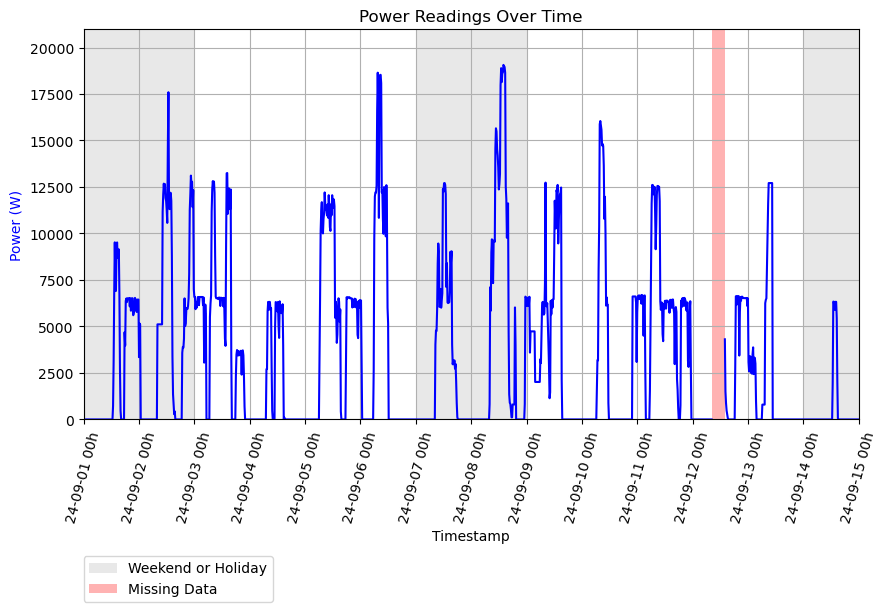

In [171]:
# create the subframe
sub_power_df = df.query(f"date >= '{start_date}' and date <= '{end_date}'").copy()
sub_power_df = sub_power_df.set_index("date").asfreq("15min").reset_index()
sub_power_df["isArtificialData"] = sub_power_df["power"].isna()
cal = us_calendar()
holidays = cal.holidays(start=start_date, end=end_date)
sub_power_df["isHoliday"] = sub_power_df["date"].dt.date.isin(holidays.date)
sub_power_df = interpolate_missing_data(sub_power_df)


# Plot the graph

fig, ax1 = plt.subplots(figsize=(10, 5))
# ax2 = ax1.twinx()
ax1.plot(sub_power_df["date"], sub_power_df["power"], color="blue")
ax1.set_ylabel("Power (W)", color="blue")
ymax = sub_power_df["power"].max() * 1.1
ax1.set_ylim(0, ymax)
# add background color for weekends and public holidays
ax1.bar(
    sub_power_df["date"],
    ymax * (abs(sub_power_df["workday"] - 1) + sub_power_df["isHoliday"]),
    width=pd.Timedelta("15Min"),
    align="edge",
    color="lightgrey",
    alpha=0.5,
    label="Weekend or Holiday",
)
# add background color for missing data
ax1.bar(
    sub_power_df["date"],
    ymax * sub_power_df["isArtificialData"],
    width=pd.Timedelta("15Min"),
    align="edge",
    color="red",
    alpha=0.3,
    label="Missing Data",
)


# if mode == "active_sessions":
#     ax2.plot(
#         sub_power_df["date"],
#         sub_power_df["numberOfActiveSessions"],
#         color="green",
#         alpha=0.7,
#     )
#     ax2.set_ylabel("Number of Active Sessions", color="green")
#     ax2.set_ylim(0, 10)
# elif mode == "price":
#     ax2.plot(
#         sub_power_df["date"],
#         sub_power_df["averageRegularPricePerHour"],
#         color="purple",
#         label="Average Regular Price",
#     )
#     ax2.plot(
#         sub_power_df["date"],
#         sub_power_df["reg_centsPerHr"].ffill(),
#         color="pink",
#         alpha=0.7,
#         label="Regular Price from sessions",
#     )
#     ax2.plot(
#         sub_power_df["date"],
#         sub_power_df["averageScheduledPricePerHour"],
#         color="green",
#         label="Average Scheduled Price",
#     )
#     ax2.plot(
#         sub_power_df["date"],
#         sub_power_df["sch_centsPerHr"].ffill(),
#         color="lightgreen",
#         alpha=0.7,
#         label="Scheduled Price from sessions",
#     )

#     ax2.set_ylabel("Price per hour", color="green")
#     ax2.legend(bbox_to_anchor=(0.3, -0.35), loc="upper left", borderaxespad=0)

# Customize the plot

plt.title("Power Readings Over Time")


# set the time ticks
desired_frequencies = [2, 4, 6, 12, 24, 48, 96, 168, 336, 720, 1440]
x_axis_freq = int(
    (end_date - start_date).total_seconds() / 3600 // number_of_time_ticks
)
# Select the desired frequency that is closest to but not greater than the initial frequency
x_axis_freq = max([freq for freq in desired_frequencies if freq <= x_axis_freq * 1.3])
print(
    f"Using x-axis frequency of {x_axis_freq} hours in order to display around {number_of_time_ticks} ticks."
)
x_axis_freq = f"{x_axis_freq}h"
ax1.set_xlim(start_date, end_date)

ax1.set_xticks(pd.date_range(start_date, end_date, freq=x_axis_freq))

ax1.set_xticklabels(
    pd.date_range(start_date, end_date, freq=x_axis_freq).strftime("%y-%m-%d %Hh"),
    rotation=75,
)
ax1.set_xlabel("Timestamp")

ax1.legend(bbox_to_anchor=(0, -0.35), loc="upper left", borderaxespad=0)
plt.grid(True)
fig.subplots_adjust(bottom=0.1)

# Show the plot

plt.show()